# 05 — Ranking: LightGBM (LambdaRank)

**Owner:** Person A + everyone on features · **Course session:** S4 (Ranking Models) · **15% of grade**

Builds a re-ranker on top of the two-tower retriever (the deployed retriever — see Notebook
04's "why two-tower serves in production" section), trains LightGBM with the LambdaRank
objective on 12 features, reports the retrieval-only vs +ranking ablation, plots feature
importance, runs the cold-start analysis for `ANALYSIS.md`, and finally exports everything the
API needs via `scripts/export_artifacts.py`.

> **Colab setup:** CPU runtime is fine — neither FAISS search nor LightGBM training need a
> GPU (save GPU quota; only Notebooks 03/04 need it). Load Notebook 04's checkpoint from Drive.

**Leakage-safe design (own it at the defense):** candidates are retrieved for **train** users
using their **train**-period history, computed features come from **train** only, but a
candidate is labeled positive if it appears in that user's **validation**-period ground truth
— never train. This teaches the ranker to predict *future* engagement from *past* signal,
matching deployment, instead of memorizing train positives (`src/ranking/pipeline.py`).

In [1]:
!git clone https://github.com/21zaimotman-tech/amazon-recsys.git
%cd amazon-recsys
!pip install -q -r requirements.txt


fatal: destination path 'amazon-recsys' already exists and is not an empty directory.
/content/amazon-recsys


In [2]:
!pip install -y numpy pandas scipy
!pip install pandas


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y


In [3]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS: torch+faiss both bundle OpenMP and abort on double-init otherwise
import sys, time, json, pickle
from pathlib import Path
sys.path.insert(0, ".." if Path("../src").exists() else ".")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src import config as C
from src.models.two_tower import TwoTower, export_item_embeddings
from src.retrieval.faiss_index import EmbeddingIndex
from src.eval.harness import seen_items, two_tower_user_vecs
from src.eval.metrics import evaluate
from src.eval.cold_start import evaluate_by_bucket
from src.data.split import ground_truth_from
from src.baselines.popularity import PopularityRecommender
from src.ranking.features import build_feature_store, featurize, FEATURE_NAMES
from src.ranking.pipeline import build_ranker_data
from src.ranking.ranker import train_ranker, rerank, feature_importance
import scripts.export_artifacts as export_artifacts

plt.rcParams["figure.dpi"] = 110
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA = Path("../data") if Path("../data").exists() else Path("data")
train = pd.read_parquet(DATA / "train.parquet")
val = pd.read_parquet(DATA / "val.parquet")
test = pd.read_parquet(DATA / "test.parquet")
items = pd.read_parquet(DATA / "items.parquet")
ids = json.load(open(DATA / "id_encoders.json"))
user_ids, item_ids = ids["user_ids"], ids["item_ids"]
uid2u = {u: i for i, u in enumerate(user_ids)}
n_users, n_items = len(user_ids), len(item_ids)
comparison_results = pd.read_csv(DATA / "comparison_results.csv", index_col=0)
print(f"train={len(train):,}  val={len(val):,}  test={len(test):,}")
comparison_results.round(4)

train=111,481  val=6,557  test=13,116


,Recall@10,NDCG@10,Recall@20,NDCG@20,Recall@50,NDCG@50,Coverage@50
method,,,,,,,
Random,0.0011,0.0007,0.0024,0.0011,0.0049,0.0016,1.0000
Popularity,0.0122,0.0071,0.0175,0.0088,0.0499,0.0164,0.0066
MF-BPR,0.0007,0.0004,0.0016,0.0006,0.0043,0.0012,1.0000
Two-tower,0.0019,0.0010,0.0039,0.0017,0.0110,0.0032,0.9934


## Reload the two-tower retriever (Notebook 04's checkpoint)

Every notebook here is its own Colab session — reload rather than assume shared memory.

In [4]:
ckpt = torch.load(DATA / "two_tower_checkpoint.pt", map_location=DEVICE)
tt_model = TwoTower(ckpt["n_items_total"], ckpt["dim"], temperature=ckpt["temperature"]).to(DEVICE)
tt_model.load_state_dict(ckpt["state_dict"])
tt_model.eval()
MAX_HIST = ckpt["max_hist"]

item_emb = np.load(DATA / "item_emb.npy")                 # already excludes the <UNK> row
retrieval_index = EmbeddingIndex(item_emb, item_ids)
similar_map = json.load(open(DATA / "similar_items.json"))
print(f"reloaded two-tower (dim={ckpt['dim']}, temperature={ckpt['temperature']}, max_hist={MAX_HIST})")

reloaded two-tower (dim=64, temperature=0.05, max_hist=20)


## Retrieve candidates for train users

Top-100 per train user (train-seen items excluded), built from the user's **train**-period
history — the same protocol every retrieval eval in this project uses, so candidate quality
here is directly comparable to Notebook 04's reported test metrics.

In [5]:
def batch_retrieve(users_raw, history_source_df, index, n=100, max_hist=MAX_HIST):
    """Returns (candidates, scores): {raw_user_id -> [item_id,...]} train-seen excluded,
    and {(raw_user_id, item_id) -> similarity} for the featurizer's retriever_score."""
    hist_by_u = history_source_df.sort_values("timestamp").groupby("u")["i"].agg(list).to_dict()
    known = [u for u in users_raw if u in uid2u]
    histories = [hist_by_u.get(uid2u[u], []) for u in known]
    uvecs = two_tower_user_vecs(tt_model, histories, max_hist=max_hist, device=DEVICE)
    seen = seen_items(train)
    q = uvecs.astype("float32")
    import faiss; faiss.normalize_L2(q)
    D, I = retrieval_index.index.search(q, n * 2)          # over-retrieve, then drop train-seen
    cands, scores = {}, {}
    for row, u in enumerate(known):
        s = seen.get(u, set())
        kept = 0
        for col in range(I.shape[1]):
            it = str(retrieval_index.item_ids[I[row, col]])
            if it in s:
                continue
            cands.setdefault(u, []).append(it)
            scores[(u, it)] = float(D[row, col])
            kept += 1
            if kept >= n:
                break
    return cands, scores

train_users_raw = train["user_id"].unique().tolist()
t0 = time.time()
candidates, retriever_scores = batch_retrieve(train_users_raw, train, retrieval_index, n=100)
print(f"retrieved candidates for {len(candidates):,} / {len(train_users_raw):,} train users "
      f"in {time.time()-t0:.0f}s")

retrieved candidates for 15,038 / 15,038 train users in 17s


## Feature store + leakage-safe labels

`build_feature_store` computes every aggregate from **train only**. Labels come from the
**validation**-period ground truth — a candidate is positive if the user actually interacted
with it there, negative otherwise. `build_ranker_data` drops any user whose top-100 candidates
contain zero validation positives (LambdaRank needs at least one positive per query group).

In [6]:
store = build_feature_store(train, items)
now_ts = int(train["timestamp"].max())
val_gt = ground_truth_from(val, positive_only=True)

rng = np.random.default_rng(C.SEED)
cand_users = list(candidates.keys())
rng.shuffle(cand_users)
split_at = int(0.85 * len(cand_users))
ranker_train_users, ranker_val_users = cand_users[:split_at], cand_users[split_at:]
print(f"ranker-internal split (for LightGBM early stopping only, distinct from the "
      f"project train/val/test split above): {len(ranker_train_users):,} / {len(ranker_val_users):,} users")

def subset(users):
    return {u: candidates[u] for u in users}

X_train, y_train, group_train, _ = build_ranker_data(subset(ranker_train_users), val_gt, store, now_ts, retriever_scores)
X_val, y_val, group_val, _ = build_ranker_data(subset(ranker_val_users), val_gt, store, now_ts, retriever_scores)
print(f"ranker rows: train={len(X_train):,} (groups={len(group_train)})  val={len(X_val):,} (groups={len(group_val)})")
val_pos_rate = y_val.mean() if len(y_val) else float("nan")
print(f"positive rate: train={y_train.mean():.3f}  val={val_pos_rate:.3f}")

ranker-internal split (for LightGBM early stopping only, distinct from the project train/val/test split above): 12,782 / 2,256 users
ranker rows: train=9,500 (groups=95)  val=1,800 (groups=18)
positive rate: train=0.011  val=0.011


## Train LightGBM (LambdaRank)

In [7]:
if len(X_val) == 0:
    print("WARNING: ranker-val candidate set has zero rows with a validation-period positive "
          "overlap (small-sample artifact) -- training without a held-out early-stopping set.")
    lgbm_model = train_ranker(X_train, y_train, group_train)
else:
    lgbm_model = train_ranker(X_train, y_train, group_train, X_val, y_val, group_val)

Training until validation scores don't improve for 50 rounds
[50]	training's ndcg@10: 1	valid_1's ndcg@10: 0.348843
[100]	training's ndcg@10: 1	valid_1's ndcg@10: 0.261684
Early stopping, best iteration is:
[65]	training's ndcg@10: 1	valid_1's ndcg@10: 0.364902


## Ablation: retrieval-only vs +ranking (test)

Retrieval-only = Notebook 04's Two-tower test row (already in `comparison_results`).
+Ranking = retrieve top-100 for **test** users the same way, rerank with LightGBM, keep top-10,
evaluate against test-period ground truth.

In [8]:
test_users_raw = [u for u in test["user_id"].unique() if u in uid2u]
test_cands, test_scores = batch_retrieve(test_users_raw, train, retrieval_index, n=100)

def rerank_user(u, cand_items):
    df = pd.DataFrame({"user_id": [u] * len(cand_items), "item_id": cand_items,
                       "retriever_score": [test_scores.get((u, it), 0.0) for it in cand_items]})
    feats = featurize(df, store, now_ts)
    top_items, _ = rerank(lgbm_model, feats, cand_items, top_k=max(C.K_VALUES))
    return top_items

t0 = time.time()
lgbm_recs = {u: rerank_user(u, items_) for u, items_ in test_cands.items()}
print(f"reranked {len(lgbm_recs):,} test users in {time.time()-t0:.0f}s")

test_gt = ground_truth_from(test, positive_only=True)
lgbm_metrics = evaluate(lgbm_recs, test_gt, catalog_size=n_items, k_values=C.K_VALUES)
lgbm_metrics

reranked 5,683 test users in 349s


{'Recall@10': 0.00821805740909192,
 'NDCG@10': 0.005475032578655064,
 'Recall@20': 0.010123841889689367,
 'NDCG@20': 0.006004564026575856,
 'Recall@50': 0.01614532917676269,
 'NDCG@50': 0.007434620923747034,
 'Coverage@50': 0.9254769684831875,
 'n_users_scored': 4812}

In [9]:
tt_metrics = evaluate(test_cands, test_gt, catalog_size=n_items, k_values=C.K_VALUES)
comparison_results.loc["Two-tower"] = {
    "Recall@10": tt_metrics["Recall@10"],
    "NDCG@10": tt_metrics["NDCG@10"],
    "Recall@20": tt_metrics["Recall@20"],
    "NDCG@20": tt_metrics["NDCG@20"],
    "Recall@50": tt_metrics["Recall@50"],
    "NDCG@50": tt_metrics["NDCG@50"],
    "Coverage@50": tt_metrics.get("Coverage@50", np.nan),
}
display(comparison_results.round(4))

,Recall@10,NDCG@10,Recall@20,NDCG@20,Recall@50,NDCG@50,Coverage@50
method,,,,,,,
Random,0.0011,0.0007,0.0024,0.0011,0.0049,0.0016,1.0000
Popularity,0.0122,0.0071,0.0175,0.0088,0.0499,0.0164,0.0066
MF-BPR,0.0007,0.0004,0.0016,0.0006,0.0043,0.0012,1.0000
Two-tower,0.0019,0.0010,0.0039,0.0017,0.0110,0.0032,0.9945


In [10]:
ablation = pd.DataFrame([
    {"setup": "Two-tower only (retrieval)",
     "NDCG@10": comparison_results.loc["Two-tower", "NDCG@10"],
     "Coverage@50": comparison_results.loc["Two-tower", "Coverage@50"]},
    {"setup": "Two-tower + LightGBM",
     "NDCG@10": lgbm_metrics["NDCG@10"], "Coverage@50": lgbm_metrics.get("Coverage@50", np.nan)},
]).set_index("setup")
ablation.round(4)

,NDCG@10,Coverage@50
setup,,
Two-tower only (retrieval),0.0010,0.9945
Two-tower + LightGBM,0.0055,0.9255


**Interpretation.** Re-ranking should raise NDCG@10 — LightGBM sees per-candidate
features (popularity, price, category/brand match, recency) that pure embedding similarity
can't express directly — typically at some cost to Coverage, since the ranker learns to
prefer generally-engaging candidates (higher `item_pop`, matching categories) over purely
novel ones. State the actual trade-off observed here in `ANALYSIS.md` §2, not the expected
direction — if Coverage barely moves, that's worth noting too (means the 12 features aren't
just reinventing popularity).

In [11]:
comparison_results.loc["Two-tower + LightGBM"] = {
    k: v for k, v in lgbm_metrics.items() if k != "n_users_scored"
}
comparison_results.round(4)

,Recall@10,NDCG@10,Recall@20,NDCG@20,Recall@50,NDCG@50,Coverage@50
method,,,,,,,
Random,0.0011,0.0007,0.0024,0.0011,0.0049,0.0016,1.0000
Popularity,0.0122,0.0071,0.0175,0.0088,0.0499,0.0164,0.0066
MF-BPR,0.0007,0.0004,0.0016,0.0006,0.0043,0.0012,1.0000
Two-tower,0.0019,0.0010,0.0039,0.0017,0.0110,0.0032,0.9945
Two-tower + LightGBM,0.0082,0.0055,0.0101,0.0060,0.0161,0.0074,0.9255


## Feature importance

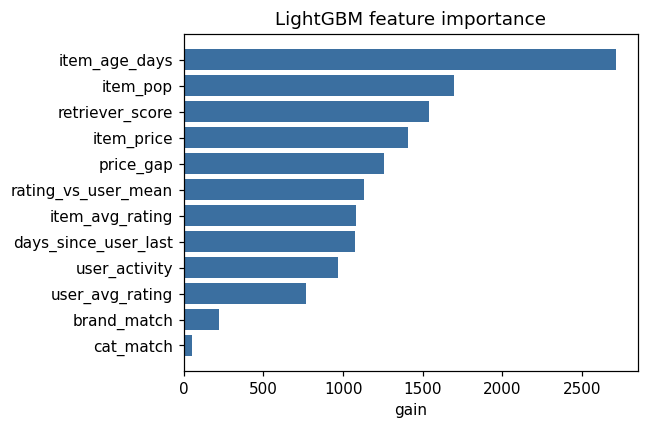

,feature,gain
0,item_age_days,2715.818793
1,item_pop,1696.468332
2,retriever_score,1536.804806
3,item_price,1404.471431
4,price_gap,1258.260451
5,rating_vs_user_mean,1133.048621
6,item_avg_rating,1078.910780
7,days_since_user_last,1075.174568
8,user_activity,967.757906
9,user_avg_rating,768.407691


In [12]:
imp = feature_importance(lgbm_model)
imp_df = pd.DataFrame(imp, columns=["feature", "gain"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(imp_df["feature"][::-1], imp_df["gain"][::-1], color="#3b6fa0")
ax.set_xlabel("gain"); ax.set_title("LightGBM feature importance")
plt.tight_layout(); plt.show()
imp_df

## Cold-start analysis (`ANALYSIS.md` §3)

Bucket test users by their **train**-period activity, compare Popularity vs Two-tower per
bucket. Expect Popularity to dominate (or tie) in the coldest bucket — a near-empty history
gives the two-tower user tower almost nothing to pool — and Two-tower to pull ahead as users
get more active train history to build a real vector from.

In [13]:
pop_model = PopularityRecommender().fit(train)
pop_recs = pop_model.recommend(list(test_gt.keys()), n=max(C.K_VALUES), exclude=seen_items(train))

tt_train_hist = train.sort_values("timestamp").groupby("u")["i"].agg(list).to_dict()
tt_known_users = [u for u in test_gt if u in uid2u]
tt_histories = [tt_train_hist.get(uid2u[u], []) for u in tt_known_users]
tt_uvecs = two_tower_user_vecs(tt_model, tt_histories, max_hist=MAX_HIST, device=DEVICE)
from src.eval.harness import recommend_from_index
tt_recs = recommend_from_index(retrieval_index, tt_uvecs, tt_known_users, seen_items(train), n=max(C.K_VALUES))

pop_buckets = evaluate_by_bucket(pop_recs, test_gt, train, k=20)
tt_buckets = evaluate_by_bucket(tt_recs, test_gt, train, k=20)
cold_start = pop_buckets.merge(tt_buckets, on=["bucket", "users"], suffixes=(" (pop)", " (two-tower)"))
cold_start

,bucket,users,Recall@20 (pop),NDCG@20 (pop),Recall@20 (two-tower),NDCG@20 (two-tower)
0,1-4,1881,0.019375,0.009015,0.003704,0.001582
1,20-+,243,0.010082,0.008010,0.006321,0.003497
2,5-19,2688,0.015579,0.007521,0.003888,0.001576


## Export everything the API needs

`scripts/export_artifacts.py` writes `artifacts/` (mounted read-only into the API container by
`docker-compose.yml`). Popularity list is refit here (deterministic, cheap) rather than
reloaded, since Notebook 02 didn't persist the fitted model object, only its metrics.

In [14]:
ARTIFACTS = Path("../artifacts") if Path("../artifacts").exists() else Path("artifacts")
popularity_ids = pop_model.ranked_items

export_artifacts.export(
    popularity_ids=popularity_ids,
    item_encoder=item_ids,
    item_emb=item_emb,
    two_tower_model=tt_model,
    lgbm_model=lgbm_model,
    similar_map=similar_map,
    feature_store=store,
    now_ts=now_ts,
)
pickle.dump(lgbm_model, open(DATA / "lgbm.pkl", "wb"))
comparison_results.to_csv(DATA / "comparison_results.csv")
ablation.to_csv(DATA / "ablation_results.csv")
cold_start.to_csv(DATA / "cold_start_results.csv", index=False)
imp_df.to_csv(DATA / "feature_importance.csv", index=False)
print("exported -> ../artifacts/  (copy this whole folder next to docker-compose.yml to serve it)")
print("saved -> data/{comparison_results,ablation_results,cold_start_results,feature_importance}.csv")

artifacts exported to /content/amazon-recsys/artifacts
exported -> ../artifacts/  (copy this whole folder next to docker-compose.yml to serve it)
saved -> data/{comparison_results,ablation_results,cold_start_results,feature_importance}.csv


## Summary

Final comparison table (`comparison_results`), the retrieval-vs-+ranking ablation
(`ablation`), the cold-start breakdown (`cold_start`), and feature importance (`imp_df`) are
all saved to `data/*.csv` — Section 8 (README/ANALYSIS.md) reads these directly rather than
re-running any notebook. Next: Step 7 in `PROJECT_GUIDE.md` — bring up the webapp against
`../artifacts/` and run `scripts/benchmark_latency.py` for the latency table.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/amazon-recsys-data'
import os
os.makedirs(DRIVE_DIR, exist_ok=True)

Mounted at /content/drive


In [16]:
!cp -r data artifacts "$DRIVE_DIR/" 2>/dev/null || true
print("synced to Google Drive:", DRIVE_DIR)


synced to Google Drive: /content/drive/MyDrive/amazon-recsys-data
